In [1]:
from google.colab import files
uploaded = files.upload()

Saving train_DUMM_dots_commas.csv to train_DUMM_dots_commas.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving test_DUMM_dots_commas.csv to test_DUMM_dots_commas.csv


In [3]:
import os
os.listdir()

['.config',
 'test_DUMM_dots_commas.csv',
 'train_DUMM_dots_commas.csv',
 'sample_data']

✓ Datos cargados
  Train: 576 obs | 14 variables
  Test:  192 obs
  Variables: ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation_3', 'orientation_4', 'orientation_5', 'glazing_area_modified', 'glazing_dist_2', 'glazing_dist_3', 'glazing_dist_4', 'glazing_dist_5', 'glazing_dist_6']

  ANÁLISIS DE SENSIBILIDAD A HIPERPARÁMETROS

── n_estimators (max_depth=None, max_features='sqrt') ──
  n=   50 → R²_train=0.9979  RMSE_train=0.4658 | R²_test=0.9847  RMSE_test=1.2544
  n=  100 → R²_train=0.9981  RMSE_train=0.4393 | R²_test=0.9851  RMSE_test=1.2388
  n=  200 → R²_train=0.9981  RMSE_train=0.4361 | R²_test=0.9864  RMSE_test=1.1797
  n=  300 → R²_train=0.9981  RMSE_train=0.4364 | R²_test=0.9865  RMSE_test=1.1777
  n=  500 → R²_train=0.9982  RMSE_train=0.4273 | R²_test=0.9866  RMSE_test=1.1750
  n= 1000 → R²_train=0.9983  RMSE_train=0.4199 | R²_test=0.9866  RMSE_test=1.1748

── max_depth (n=500, max_features='sqrt') ──
  depth=3                → R

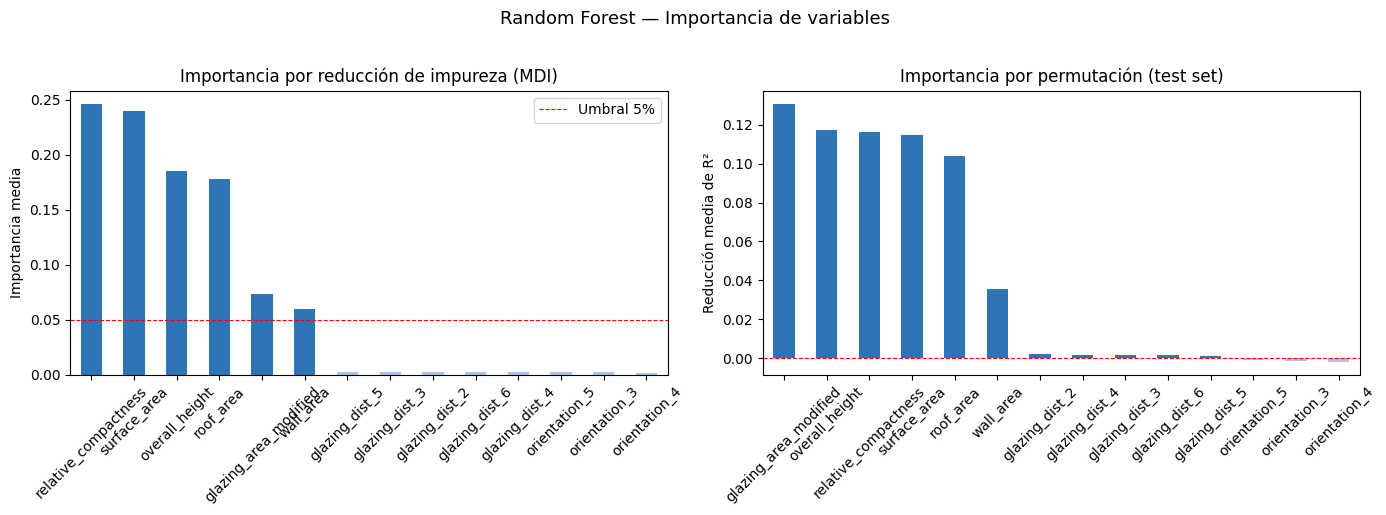

✓ Guardado: RF_importancia_variables.png


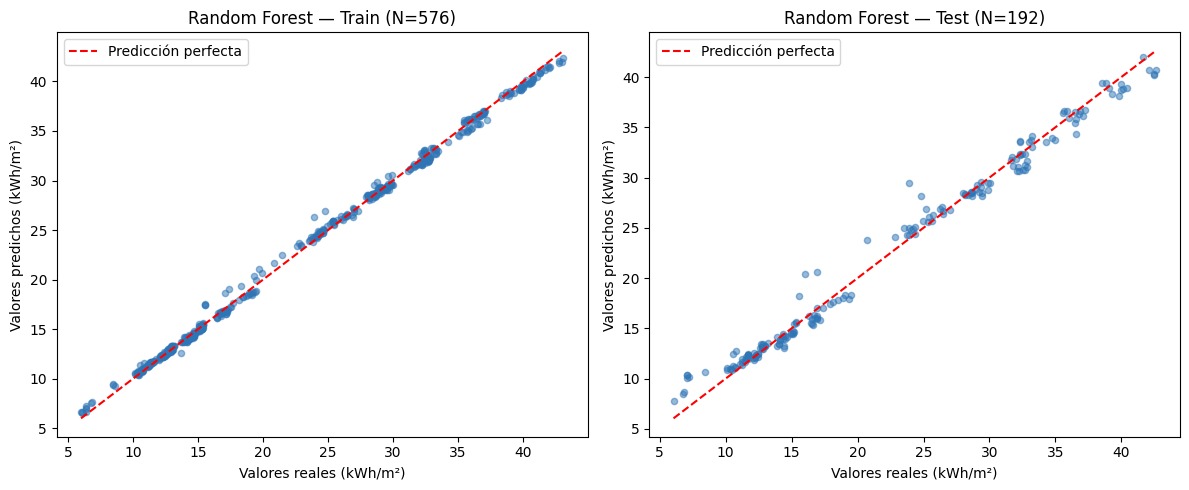

✓ Guardado: RF_predichos_vs_reales.png


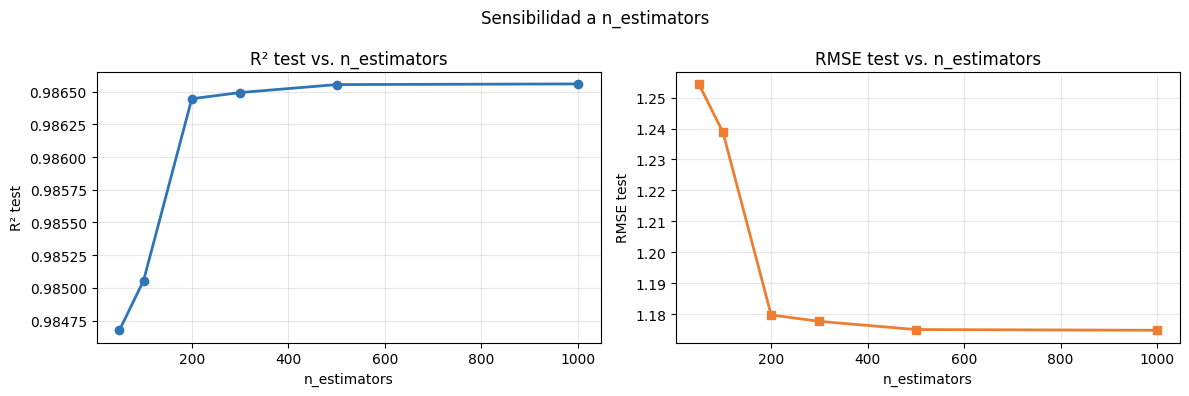

✓ Guardado: RF_sensibilidad_n.png


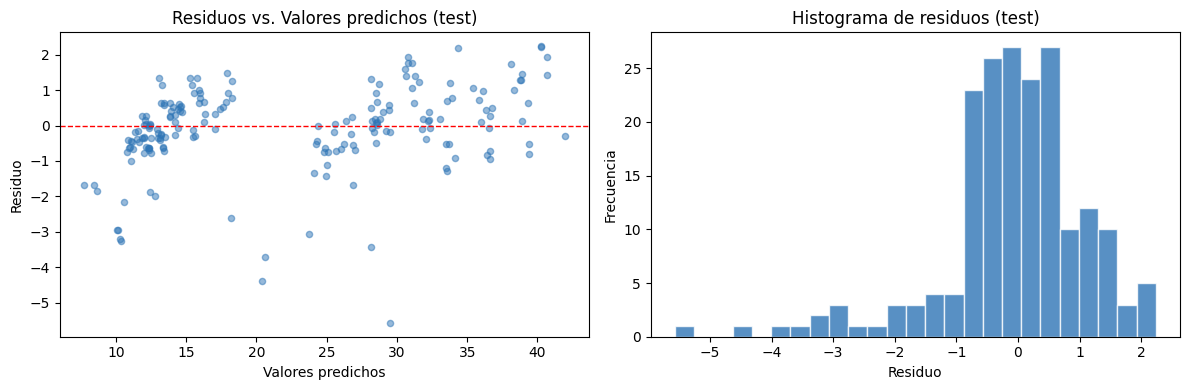

✓ Guardado: RF_residuos.png

  ✅ RANDOM FOREST COMPLETADO
  R²_test=0.9866 | RMSE_test=1.1750 | MAPE=4.99%
  Tiempo: 1.03 s

Archivos generados:
  - RF_importancia_variables.png
  - RF_predichos_vs_reales.png
  - RF_sensibilidad_n.png
  - RF_residuos.png


In [4]:
# ============================================================
#  4.4 RANDOM FOREST — Trabajo Final Econometría
#  Base: Tsanas & Xifara (2012) — Heating Load
#  IMPORTANTE: subir train_DUMM_dots_commas.csv y
#              test_DUMM_dots_commas.csv antes de ejecutar
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

# ── 1. CARGAR DATOS Y CORREGIR DUMMIES ───────────────────────────────────────
train = pd.read_csv('train_DUMM_dots_commas.csv')
test  = pd.read_csv('test_DUMM_dots_commas.csv')
train.columns = train.columns.str.replace('\ufeff', '')
test.columns  = test.columns.str.replace('\ufeff', '')

TARGET = 'heating_load'
REF    = ['orientation_2', 'glazing_dist_1']  # mismas refs que MCO y Lasso

X_train = train.drop(columns=[TARGET] + REF)
y_train = train[TARGET].values
X_test  = test.drop(columns=[TARGET] + REF)
y_test  = test[TARGET].values
feature_names = X_train.columns.tolist()
X_train = X_train.values
X_test  = X_test.values

print(f"✓ Datos cargados")
print(f"  Train: {X_train.shape[0]} obs | {X_train.shape[1]} variables")
print(f"  Test:  {X_test.shape[0]} obs")
print(f"  Variables: {feature_names}")

# ── 2. MODELO BASE — ANÁLISIS DE SENSIBILIDAD PREVIO ─────────────────────────
# Primero buscamos los hiperparámetros óptimos, luego estimamos el modelo final

print("\n" + "="*60)
print("  ANÁLISIS DE SENSIBILIDAD A HIPERPARÁMETROS")
print("="*60)

# 2a. Sensibilidad n_estimators
print("\n── n_estimators (max_depth=None, max_features='sqrt') ──")
sens_n = []
for n in [50, 100, 200, 300, 500, 1000]:
    rf_n = RandomForestRegressor(n_estimators=n, max_depth=None,
                                  max_features='sqrt', random_state=42, n_jobs=-1)
    rf_n.fit(X_train, y_train)
    r2_te   = r2_score(y_test, rf_n.predict(X_test))
    rmse_te = np.sqrt(mean_squared_error(y_test, rf_n.predict(X_test)))
    r2_tr   = r2_score(y_train, rf_n.predict(X_train))
    rmse_tr = np.sqrt(mean_squared_error(y_train, rf_n.predict(X_train)))
    sens_n.append((n, r2_tr, rmse_tr, r2_te, rmse_te))
    print(f"  n={n:>5d} → R²_train={r2_tr:.4f}  RMSE_train={rmse_tr:.4f} | R²_test={r2_te:.4f}  RMSE_test={rmse_te:.4f}")

# 2b. Sensibilidad max_depth
print("\n── max_depth (n=500, max_features='sqrt') ──")
sens_d = []
for d in [3, 5, 8, 10, 15, None]:
    rf_d = RandomForestRegressor(n_estimators=500, max_depth=d,
                                  max_features='sqrt', random_state=42, n_jobs=-1)
    rf_d.fit(X_train, y_train)
    r2_te   = r2_score(y_test, rf_d.predict(X_test))
    rmse_te = np.sqrt(mean_squared_error(y_test, rf_d.predict(X_test)))
    r2_tr   = r2_score(y_train, rf_d.predict(X_train))
    rmse_tr = np.sqrt(mean_squared_error(y_train, rf_d.predict(X_train)))
    etiq = str(d) if d else 'None (sin límite)'
    sens_d.append((etiq, r2_tr, rmse_tr, r2_te, rmse_te))
    print(f"  depth={etiq:<16} → R²_train={r2_tr:.4f}  RMSE_train={rmse_tr:.4f} | R²_test={r2_te:.4f}  RMSE_test={rmse_te:.4f}")

# 2c. Sensibilidad max_features
print("\n── max_features (n=500, max_depth=None) ──")
sens_f = []
for f in ['sqrt', 'log2', 0.5, 1.0]:
    rf_f = RandomForestRegressor(n_estimators=500, max_depth=None,
                                  max_features=f, random_state=42, n_jobs=-1)
    rf_f.fit(X_train, y_train)
    r2_te   = r2_score(y_test, rf_f.predict(X_test))
    rmse_te = np.sqrt(mean_squared_error(y_test, rf_f.predict(X_test)))
    r2_tr   = r2_score(y_train, rf_f.predict(X_train))
    rmse_tr = np.sqrt(mean_squared_error(y_train, rf_f.predict(X_train)))
    sens_f.append((str(f), r2_tr, rmse_tr, r2_te, rmse_te))
    print(f"  max_features={str(f):<6} → R²_train={r2_tr:.4f}  RMSE_train={rmse_tr:.4f} | R²_test={r2_te:.4f}  RMSE_test={rmse_te:.4f}")

# ── 3. MODELO FINAL ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  MODELO FINAL")
print("="*60)

t0 = time.time()
rf = RandomForestRegressor(
    n_estimators  = 500,      # suficientes árboles, estable
    max_depth     = None,     # sin límite de profundidad
    max_features  = 'sqrt',   # estándar para regresión
    min_samples_leaf = 1,     # hojas puras
    random_state  = 42,
    n_jobs        = -1
)
rf.fit(X_train, y_train)
t_rf = time.time() - t0

yp_tr = rf.predict(X_train)
yp_te = rf.predict(X_test)

r2_tr   = r2_score(y_train, yp_tr)
r2_te   = r2_score(y_test,  yp_te)
rmse_tr = np.sqrt(mean_squared_error(y_train, yp_tr))
rmse_te = np.sqrt(mean_squared_error(y_test,  yp_te))
mae_tr  = mean_absolute_error(y_train, yp_tr)
mae_te  = mean_absolute_error(y_test,  yp_te)
mape_te = np.mean(np.abs((y_test - yp_te) / y_test)) * 100
media_y = y_train.mean()
dt_y    = y_train.std()
rss     = ((y_train - yp_tr)**2).sum()

print(f"\n── TRAIN ──")
print(f"R²:   {r2_tr:.4f}")
print(f"RMSE: {rmse_tr:.4f}")
print(f"MAE:  {mae_tr:.4f}")
print(f"RSS:  {rss:.4f}")
print(f"\n── TEST ──")
print(f"R²:   {r2_te:.4f}")
print(f"RMSE: {rmse_te:.4f}")
print(f"MAE:  {mae_te:.4f}")
print(f"MAPE: {mape_te:.2f}%")
print(f"\nTiempo de ejecución: {t_rf:.2f} s")
print(f"Media Y train: {media_y:.4f}")
print(f"D.T. Y train:  {dt_y:.4f}")

# ── 4. IMPORTANCIA DE VARIABLES ───────────────────────────────────────────────
print("\n" + "="*60)
print("  IMPORTANCIA DE VARIABLES")
print("="*60)

# 4a. Impurity-based (MDI) — rápida pero puede estar sesgada
imp_mdi = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\n── Importancia por reducción de impureza (MDI) ──")
print(imp_mdi.round(4).to_string())

# 4b. Permutation importance — más fiable, especialmente para dummies
print("\n── Importancia por permutación (test set) ──")
perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
print(imp_perm.round(4).to_string())

# ── 5. GRÁFICOS ───────────────────────────────────────────────────────────────

# Gráfico 1: Importancia MDI vs Permutación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDI
colors_mdi = ['#2E75B6' if v > 0.05 else '#A9C4E4' for v in imp_mdi]
imp_mdi.plot(kind='bar', ax=axes[0], color=colors_mdi)
axes[0].axhline(0.05, color='red', lw=0.8, linestyle='--', label='Umbral 5%')
axes[0].set_title('Importancia por reducción de impureza (MDI)')
axes[0].set_ylabel('Importancia media')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Permutación
colors_perm = ['#2E75B6' if v > 0 else '#A9C4E4' for v in imp_perm]
imp_perm.plot(kind='bar', ax=axes[1], color=colors_perm)
axes[1].axhline(0, color='red', lw=0.8, linestyle='--')
axes[1].set_title('Importancia por permutación (test set)')
axes[1].set_ylabel('Reducción media de R²')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Random Forest — Importancia de variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('RF_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: RF_importancia_variables.png")

# Gráfico 2: Predichos vs Reales (train y test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_r, y_p, tit in zip(
    axes,
    [y_train, y_test],
    [yp_tr, yp_te],
    ['Train (N=576)', 'Test (N=192)']
):
    ax.scatter(y_r, y_p, alpha=0.5, s=20, color='#2E75B6')
    mn = min(y_r.min(), y_p.min())
    mx = max(y_r.max(), y_p.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valores reales (kWh/m²)')
    ax.set_ylabel('Valores predichos (kWh/m²)')
    ax.set_title(f'Random Forest — {tit}')
    ax.legend()
plt.tight_layout()
plt.savefig('RF_predichos_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: RF_predichos_vs_reales.png")

# Gráfico 3: Sensibilidad n_estimators
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ns    = [r[0] for r in sens_n]
r2s   = [r[3] for r in sens_n]
rmses = [r[4] for r in sens_n]
axes[0].plot(ns, r2s,   'o-', color='#2E75B6', lw=2); axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('R² test'); axes[0].set_title('R² test vs. n_estimators')
axes[1].plot(ns, rmses, 's-', color='#ED7D31', lw=2); axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('RMSE test'); axes[1].set_title('RMSE test vs. n_estimators')
for ax in axes: ax.grid(alpha=0.3)
plt.suptitle('Sensibilidad a n_estimators', fontsize=12)
plt.tight_layout()
plt.savefig('RF_sensibilidad_n.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: RF_sensibilidad_n.png")

# Gráfico 4: Residuos vs predichos
resid_te = y_test - yp_te
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(yp_te, resid_te, alpha=0.5, s=20, color='#2E75B6')
axes[0].axhline(0, color='red', lw=1, linestyle='--')
axes[0].set_xlabel('Valores predichos'); axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs. Valores predichos (test)')
axes[1].hist(resid_te, bins=25, color='#2E75B6', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residuo'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Histograma de residuos (test)')
plt.tight_layout()
plt.savefig('RF_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: RF_residuos.png")

print("\n" + "="*60)
print("  ✅ RANDOM FOREST COMPLETADO")
print(f"  R²_test={r2_te:.4f} | RMSE_test={rmse_te:.4f} | MAPE={mape_te:.2f}%")
print(f"  Tiempo: {t_rf:.2f} s")
print("="*60)
print("\nArchivos generados:")
print("  - RF_importancia_variables.png")
print("  - RF_predichos_vs_reales.png")
print("  - RF_sensibilidad_n.png")
print("  - RF_residuos.png")

In [5]:
print("\n── min_samples_leaf (n=500, max_depth=None, max_features='sqrt') ──")
for leaf in [1, 2, 5, 10]:
    rf_l = RandomForestRegressor(n_estimators=500, max_depth=None,
                                  max_features='sqrt', min_samples_leaf=leaf,
                                  random_state=42, n_jobs=-1)
    rf_l.fit(X_train, y_train)
    r2_te   = r2_score(y_test, rf_l.predict(X_test))
    rmse_te = np.sqrt(mean_squared_error(y_test, rf_l.predict(X_test)))
    print(f"  min_samples_leaf={leaf:<3} → R²_test={r2_te:.4f}  RMSE_test={rmse_te:.4f}")


── min_samples_leaf (n=500, max_depth=None, max_features='sqrt') ──
  min_samples_leaf=1   → R²_test=0.9866  RMSE_test=1.1750
  min_samples_leaf=2   → R²_test=0.9781  RMSE_test=1.4982
  min_samples_leaf=5   → R²_test=0.9654  RMSE_test=1.8859
  min_samples_leaf=10  → R²_test=0.9461  RMSE_test=2.3518
